# Codificação de Sinais Multimedia

## Trabalho Laboratorial 3

- 52146 - Margarida Andrade
- 52345 - Jorge Gonçalves
- 52708 - Helena Nina

In [66]:
import numpy as np
import matplotlib.pyplot as plt

## Exercício 1


### Exercício 1

Nesta alínea é construída uma tabela de Huffman a partir de símbolos e respetivos pesos (probabilidades ou ocorrências). A função devolve uma tabela com o código binário associado a cada símbolo e pode ser aplicada diretamente a um histograma de frequência.

In [67]:
from collections import Counter
from heapq import heappop, heappush
from itertools import count
from pathlib import Path


def gen_huff_table(symbols, probabilities=None):
    """Gera um dicionario simbolo -> codigo de Huffman.
        symbols: lista de simbolos ou dicionario {simbolo: probabilidade}
        probabilities: lista de probabilidades (opcional se symbols é dict)
    """
    if isinstance(symbols, dict):
        freq = symbols
    else:
        if probabilities is None:
            raise ValueError("probabilities deve ser fornecido quando symbols nao e um dicionario")
        freq = dict(zip(symbols, probabilities))
    
    heap = []
    order = count()
    for symbol, weight in freq.items():
        heappush(heap, (float(weight), next(order), symbol))
    
    if len(heap) == 1:
        return {heap[0][2]: "0"}
    
    while len(heap) > 1:
        w1, _, left = heappop(heap)
        w2, _, right = heappop(heap)
        heappush(heap, (w1 + w2, next(order), (left, right)))
    
    codes = {}
    def walk(node, prefix=""):
        if isinstance(node, tuple):
            walk(node[0], prefix + "0")
            walk(node[1], prefix + "1")
        else:
            codes[node] = prefix or "0"
    
    walk(heap[0][2])
    return codes


texto = Path("dados-CSM-TP3-Huffman/DecUniversalDH.txt").read_text(encoding="utf-8")
freq = Counter(texto)
total = sum(freq.values())
probs = {symbol: count / total for symbol, count in freq.items()}
codes = gen_huff_table(probs)

print(f"{'simbolo':>10} {'prob':>8} {'codigo'}")
for symbol, prob in sorted(probs.items(), key=lambda x: (-x[1], str(x[0]))):
    print(f"{repr(symbol):>10} {prob:8.4f} {codes[symbol]}")

   simbolo     prob codigo
       ' '   0.1632 110
       'e'   0.0991 001
       'a'   0.0859 000
       'o'   0.0841 1110
       'i'   0.0635 1010
       's'   0.0632 1000
       'd'   0.0536 0110
       'r'   0.0531 0101
       't'   0.0416 11110
       'n'   0.0389 10110
       'm'   0.0296 10010
       'u'   0.0280 01110
       'c'   0.0249 01000
       'l'   0.0222 111111
       'p'   0.0203 101111
      '\n'   0.0139 011110
       'g'   0.0101 1111100
       ','   0.0100 1011101
       'v'   0.0095 1011100
       '.'   0.0078 1001100
       'ç'   0.0078 0111111
       'ã'   0.0075 0111110
       'f'   0.0062 0100101
       'b'   0.0060 0100100
       'q'   0.0049 10011111
       'h'   0.0040 10011011
       'í'   0.0036 01001111
       'A'   0.0035 01001101
       'é'   0.0027 111110111
       'T'   0.0026 111110101
       'º'   0.0026 111110100
       'à'   0.0022 100111001
       'õ'   0.0022 100111010
       'á'   0.0020 100111000
       'z'   0.0019 100110100
       'j'   0.

## Exercício 2


In [68]:
def encode_huff(message, codes):
    """Codifica uma mensagem usando a tabela de Huffman.
    
    Args:
        message: string com a mensagem a codificar
        codes: dicionario {simbolo: codigo_binario}
    
    Returns:
        string com bits codificados (sequencia de 0s e 1s)
    """
    encoded = ""
    for symbol in message:
        if symbol not in codes:
            raise ValueError(f"Símbolo '{symbol}' não encontrado na tabela de Huffman")
        encoded += codes[symbol]
    return encoded


# Teste da função com a mensagem do arquivo
mensagem_teste = texto[:100]  # Pega os primeiros 100 caracteres
encoded = encode_huff(mensagem_teste, codes)

## Exercício 3

In [69]:
def decode_huff(encoded_message, codes):
    """Descodifica uma mensagem codificada com Huffman.
    
    Args:
        encoded_message: string com bits codificados (sequencia de 0s e 1s)
        codes: dicionario {simbolo: codigo_binario}
    
    Returns:
        string com a mensagem descodificada (símbolos originais)
    """
    # Inverte a tabela: código -> símbolo
    reverse_codes = {code: symbol for symbol, code in codes.items()}
    
    decoded = ""
    current_code = ""
    
    for bit in encoded_message:
        current_code += bit
        if current_code in reverse_codes:
            decoded += reverse_codes[current_code]
            current_code = ""
    
    if current_code:  # Se sobrarem bits no final
        raise ValueError(f"Código inválido no final da mensagem: '{current_code}'")
    
    return decoded


# Teste: verificar que decode_huff(encode_huff(msg)) == msg
mensagem_original = texto[:100]
encoded = encode_huff(mensagem_original, codes)
decoded = decode_huff(encoded, codes)


## Exercício 4

In [70]:
# Exercício 4: Codificar a tabela de Huffman

def encode_table(codes):
    """Codifica a tabela de Huffman numa sequência de bits.
    
    Formato da sequência binária:
    - 16 bits: número de símbolos
    - Para cada símbolo:
        * 8 bits: valor ASCII do símbolo
        * 8 bits: comprimento do código Huffman
        * N bits: o código Huffman em si
    
    Args:
        codes: dicionário {símbolo: código_binário}
    
    Returns:
        string com bits (0s e 1s) da tabela codificada
    """
    encoded_table = ""
    
    # Adiciona número de símbolos (16 bits)
    encoded_table += format(len(codes), '016b')
    
    # Codifica cada símbolo e seu código
    for symbol, code in codes.items():
        encoded_table += format(ord(symbol), '08b')  # Símbolo em 8 bits
        encoded_table += format(len(code), '08b')     # Comprimento do código em 8 bits
        encoded_table += code                        # Código Huffman
    
    return encoded_table


# Codificar a tabela
encoded_table = encode_table(codes)

# Acrescentar a sequência binária da tabela à mensagem codificada (do Ex. 2)
# Resultado final: [tabela codificada] + [mensagem codificada]
full_encoded = encoded_table + encoded


## Exercício 5

In [71]:
def write2file(bits, filename):
    """Escreve uma sequência de bits num ficheiro binário.

    O ficheiro é gravado como bytes e inclui um cabeçalho de 3 bits com o
    número de stuff bits adicionados no fim para completar o último byte.

    Args:
        bits: sequência de bits codificada (string, lista ou tuplo)
        filename: nome do ficheiro de saída

    Returns:
        tuple(Path, int): caminho do ficheiro escrito e número de stuff bits
    """
    if isinstance(bits, (list, tuple)):
        bits = ''.join(str(bit) for bit in bits)
    else:
        bits = str(bits)

    if any(bit not in '01' for bit in bits):
        raise ValueError("A sequência deve conter apenas '0' e '1'.")

    stuff_bits = (8 - ((3 + len(bits)) % 8)) % 8
    header = format(stuff_bits, '03b')
    payload_bits = header + bits + ('0' * stuff_bits)
    payload_bytes = int(payload_bits, 2).to_bytes(len(payload_bits) // 8, byteorder='big')

    output_path = Path(filename)
    output_path.write_bytes(payload_bytes)
    return output_path, stuff_bits

## Exercício 6

In [72]:
def read_file(filename):
    """Lê um ficheiro binário com bits codificados e separa tabela e mensagem.

    O formato esperado é:
    - 3 bits iniciais: número de stuff bits no fim
    - tabela Huffman codificada
    - mensagem codificada
    - stuff bits de preenchimento no fim

    Args:
        filename: nome do ficheiro a ler

    Returns:
        tuple(dict, str): tabela descodificada {simbolo: codigo} e mensagem codificada
    """
    input_path = Path(filename)
    raw_bytes = input_path.read_bytes()
    bitstream = ''.join(format(byte, '08b') for byte in raw_bytes)

    if len(bitstream) < 3:
        raise ValueError("Ficheiro inválido: não contém o cabeçalho de 3 bits.")

    stuff_bits = int(bitstream[:3], 2)
    if stuff_bits > len(bitstream) - 3:
        raise ValueError("Ficheiro inválido: número de stuff bits inconsistente.")

    payload_bits = bitstream[3:len(bitstream) - stuff_bits] if stuff_bits else bitstream[3:]

    if len(payload_bits) < 16:
        raise ValueError("Ficheiro inválido: tabela Huffman incompleta.")

    n_symbols = int(payload_bits[:16], 2)
    index = 16
    decoded_table = {}

    for _ in range(n_symbols):
        if index + 16 > len(payload_bits):
            raise ValueError("Ficheiro inválido: entrada de tabela incompleta.")

        symbol_bits = payload_bits[index:index + 8]
        code_len = int(payload_bits[index + 8:index + 16], 2)
        index += 16

        if index + code_len > len(payload_bits):
            raise ValueError("Ficheiro inválido: código Huffman incompleto.")

        code = payload_bits[index:index + code_len]
        index += code_len
        decoded_table[chr(int(symbol_bits, 2))] = code

    encoded_message = payload_bits[index:]
    return decoded_table, encoded_message

## Exercício 7
### Alínea a

Tempo para gerar tabela de Huffman:

C:\Users\marga\AppData\Local\Temp\ipykernel_13268\4239695831.py:7: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  h, bins, patches = plt.hist(x, 256, [0, 256])


 0.0004515647888183594 segundos


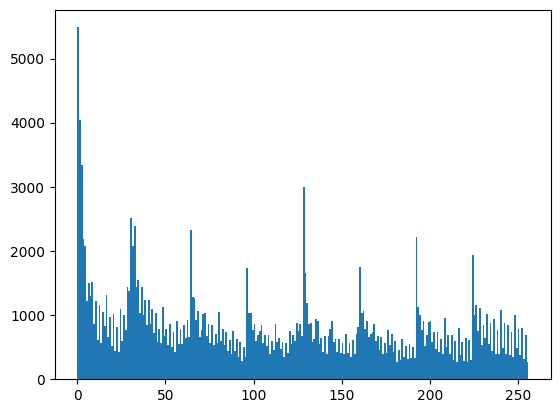

In [73]:
import numpy as np
import matplotlib.pyplot as plt
from time import time

# Exemplo para imagem grayscale
x = np.fromfile("dados-CSM-TP3-Huffman/LenaGray.tif", dtype="uint8")
h, bins, patches = plt.hist(x, 256, [0, 256])

# Gerar código de Huffman
t0 = time()
tabela_codigo = gen_huff_table(np.arange(0, 256), h)
t1 = time()
print("Tempo para gerar tabela de Huffman:", t1 - t0, "segundos")

### Alínea b

In [74]:
from math import log2

# Calcular probabilidades
prob = h / np.sum(h)
entropia = -np.sum([p * log2(p) for p in prob if p > 0])

# Número médio de bits por símbolo
media_bits = np.sum([len(tabela_codigo[s]) * prob[s] for s in range(len(prob)) if prob[s] > 0])

# Eficiência
eficiencia = entropia / media_bits

print("Entropia:", entropia)
print("Média de bits/símbolo:", media_bits)
print("Eficiência:", eficiencia)

Entropia: 7.761434296010263
Média de bits/símbolo: 7.791235567908168
Eficiência: 0.996175026202435


### Alínea c

In [75]:
t2 = time()
seq_bit0 = encode_huff(x, tabela_codigo)
t3 = time()
print("Tempo para codificar mensagem:", t3 - t2, "segundos")

Tempo para codificar mensagem: 0.12665295600891113 segundos


### Alínea d

In [78]:
seq_bit1 = encode_table(codes)
seq_total = seq_bit1 + seq_bit0  # Concatenar tabela e mensagem

filename = "LenaGray_compressed.bin"
write2file(seq_total, filename)

from os import path
size_ini = path.getsize("dados-CSM-TP3-Huffman/LenaGray.tif")
size_end = path.getsize(filename)
print("Tamanho original:", size_ini, "bytes")
print("Tamanho comprimido:", size_end, "bytes")
print("Taxa de compressão:", size_ini / size_end)

Tamanho original: 210122 bytes
Tamanho comprimido: 204838 bytes
Taxa de compressão: 1.0257959948837618


### Alínea e

In [80]:
tabela_codigo_lida, seq_bit1_lida = read_file(filename)

### Alínea f

In [81]:
t4 = time()
yi = decode_huff(seq_bit1_lida, tabela_codigo_lida)
t5 = time()
print("Tempo para descodificar mensagem:", t5 - t4, "segundos")

Tempo para descodificar mensagem: 0.16882705688476562 segundos


### Alínea g

In [82]:
# Alínea g: Comparar mensagem descodificada com a original
if np.array_equal(x, yi):
    print("Mensagem descodificada é igual à original (erro nulo).")
else:
    print("Erro: Mensagem descodificada diferente da original!")

Erro: Mensagem descodificada diferente da original!
